In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import numpy as np

participants_tsv='/nfs/trident3/lightsheet/prado/mouse_app_lecanemab_batch3/bids/participants.tsv'
spimquant_dir='/nfs/trident3/lightsheet/prado/mouse_app_lecanemab_batch3/derivatives/spimquant-v0.6.0rc2_84a605e_ozx'



In [2]:
df_participants = pd.read_csv(participants_tsv,sep='\t')
df_participants

,participant_id,lightsheet_id,genotype,sex,treatment
0,sub-AS161F3,b,ApoE3,F,PBS
1,sub-AS164F3,e,ApoE3,F,Lecanemab
2,sub-AS164F5,c,ApoE3,F,PBS
3,sub-AS165F7,f,ApoE3,F,Lecanemab
4,sub-AS168F1,a,ApoE3,F,PBS
5,sub-AS168F2,d,ApoE3,F,Lecanemab
6,sub-AS204M1,i,ApoE4,M,Lecanemab
7,sub-AS208F1,g,ApoE4,F,PBS
8,sub-AS208F2,j,ApoE4,F,Lecanemab
9,sub-AS208F3,h,ApoE4,F,PBS


In [22]:

df_list = []
for subject in df_participants.participant_id:
    
    vessel_parquet=f'{spimquant_dir}/{subject}/micr/{subject}_sample-brain_acq-imaris4x_stain-Abeta_mask-CD31_desc-otsu+k3i2_maskcoloc.parquet'
    regionprops_parquet=f'{spimquant_dir}/{subject}/micr/{subject}_sample-brain_acq-imaris4x_space-ABAv3_desc-otsu+k3i2_regionprops.parquet'
    
    if Path(vessel_parquet).exists() and Path(regionprops_parquet).exists():
        print(subject)
        _df_vessels = pd.read_parquet(vessel_parquet)
        _df_regionprops = pd.read_parquet(regionprops_parquet)
        
        #make single table 
        _df = pd.merge(left_index=True, right_index=True,left=_df_regionprops,right=_df_vessels['sdt_CD31'])
        _df['subject'] = subject
        _df['treatment'] = df_participants[df_participants.participant_id == subject]['treatment'].values[0]
        df_list.append(_df)

sub-AS161F3
sub-AS164F3


In [23]:
df = pd.concat(df_list)
df

,pos_x,pos_y,pos_z,nvoxels,template_x,template_y,template_z,stain,sdt_CD31,subject,treatment
0,5.086313,-6.701839,-0.878803,68051.0,-0.951625,1.735442,3.928544,Abeta,-0.043280,sub-AS161F3,PBS
1,5.326722,-6.720668,-0.869670,89550.0,-0.727169,1.731392,3.947663,Abeta,-0.027792,sub-AS161F3,PBS
2,6.845465,-6.752655,-0.866459,394.0,0.712155,1.785920,3.927137,Abeta,0.009044,sub-AS161F3,PBS
3,6.929629,-6.691375,-0.875280,1283.0,0.783241,1.851364,3.927456,Abeta,0.003355,sub-AS161F3,PBS
4,6.886112,-6.669221,-0.879327,331.0,0.743299,1.867367,3.917125,Abeta,0.001519,sub-AS161F3,PBS
...,...,...,...,...,...,...,...,...,...,...,...
64112,5.227707,-19.015473,-6.368087,1148.0,-0.161074,-9.585497,-1.812951,Abeta,0.016754,sub-AS164F3,Lecanemab
64113,7.767311,-18.932338,-6.504557,2293.0,2.336803,-9.472712,-1.943596,Abeta,-0.009878,sub-AS164F3,Lecanemab
64114,8.035752,-18.842948,-6.444845,1588.0,2.599264,-9.387635,-1.878090,Abeta,0.016848,sub-AS164F3,Lecanemab
64115,4.327597,-19.938242,-6.439325,358.0,-1.026893,-10.448837,-1.876343,Abeta,-0.005554,sub-AS164F3,Lecanemab


In [24]:
#add more derived vars
df['log_size'] = np.log10(df['nvoxels'])
df['abs_dist'] = np.abs(df['sdt_CD31'])


voxel_vol = 1.6 * 1.6 * 2.75  # um^3

df["plaque_vol_um3"] = df["nvoxels"] * voxel_vol
df["equiv_diam_um"] = 2 * ((3 * df["plaque_vol_um3"]) / (4 * np.pi)) ** (1/3)


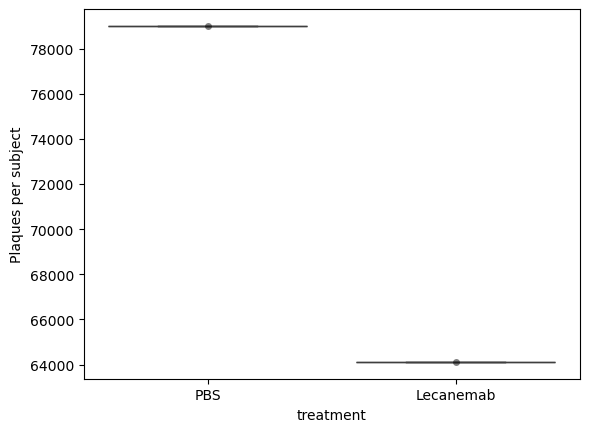

In [25]:
counts = df.groupby(['subject', 'treatment']).size().reset_index(name='n_plaques')

plt.figure()
sns.boxplot(data=counts, x='treatment', y='n_plaques')
sns.stripplot(data=counts, x='treatment', y='n_plaques', color='black', alpha=0.5)
plt.ylabel("Plaques per subject")
plt.show()

## 1️⃣ Compare plaque size distributions

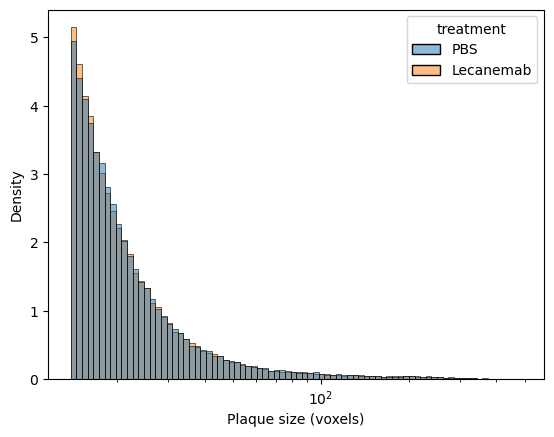

In [26]:
plt.figure()
sns.histplot(data=df, x='equiv_diam_um', hue='treatment', bins=80, log_scale=True, stat='density', common_norm=False)
plt.xlabel("Plaque size (voxels)")
plt.show()

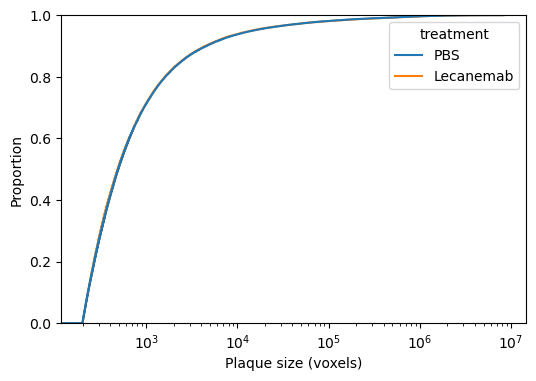

In [8]:
plt.figure(figsize=(6,4))

sns.ecdfplot(
    data=df,
    x="nvoxels",
    hue="treatment"
)

plt.xscale("log")
plt.xlabel("Plaque size (voxels)")
plt.show()

## 2️⃣ Distance to vessel distribution


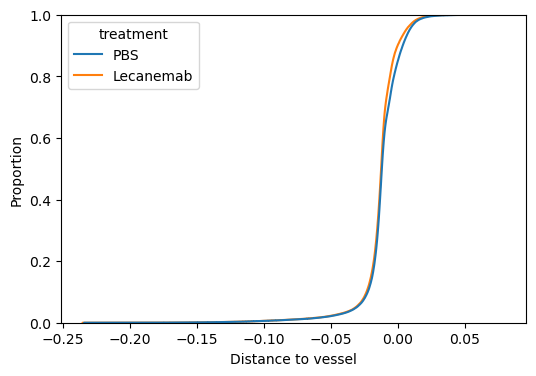

In [9]:
plt.figure(figsize=(6,4))

sns.ecdfplot(
    data=df,
    x="sdt_CD31",
    hue="treatment"
)

plt.xlabel("Distance to vessel")
plt.show()

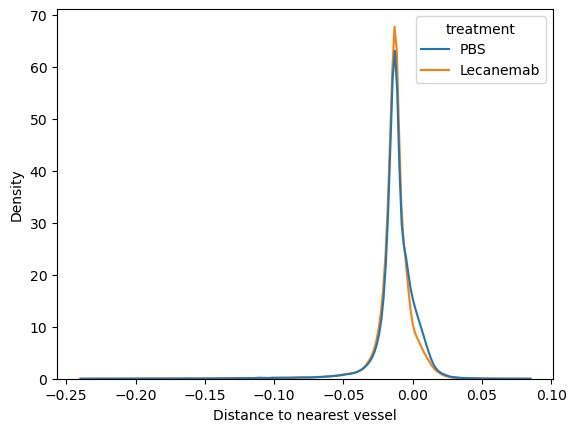

In [10]:
plt.figure()
sns.kdeplot(data=df, x='sdt_CD31', hue='treatment', common_norm=False)
plt.xlabel("Distance to nearest vessel")
plt.show()

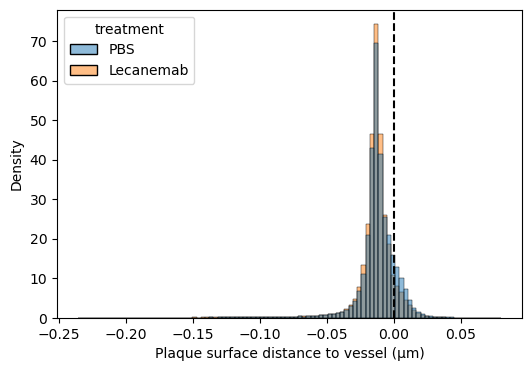

In [27]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="sdt_CD31",
    hue="treatment",
    bins=100,
    stat="density",
    common_norm=False
)

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Plaque surface distance to vessel (mm)")
plt.show()

In [29]:
df["touching_vessel"] = df["sdt_CD31"] <= 0

df.groupby("treatment")["touching_vessel"].mean()

treatment
Lecanemab    0.902771
PBS          0.851545
Name: touching_vessel, dtype: float64

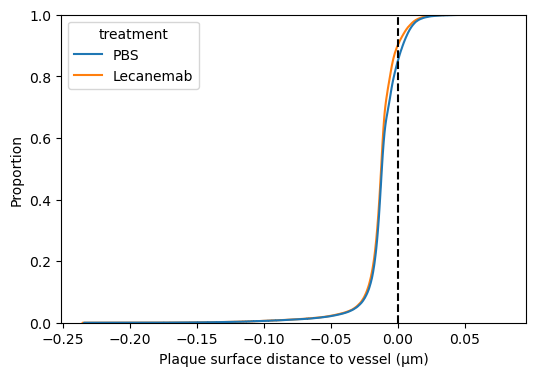

In [28]:
plt.figure(figsize=(6,4))

sns.ecdfplot(
    data=df,
    x="sdt_CD31",
    hue="treatment"
)

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Plaque surface distance to vessel (mm)")
plt.show()

## 3️⃣ Size vs vessel distance

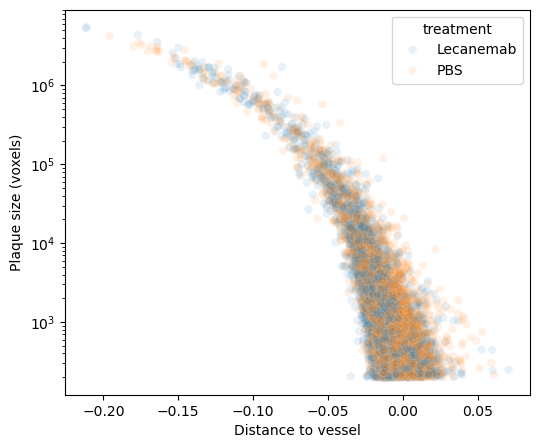

In [12]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df.sample(20000),
    x="sdt_CD31",
    y="nvoxels",
    hue="treatment",
    alpha=0.1
)

plt.yscale("log")
plt.xlabel("Distance to vessel")
plt.ylabel("Plaque size (voxels)")
plt.show()

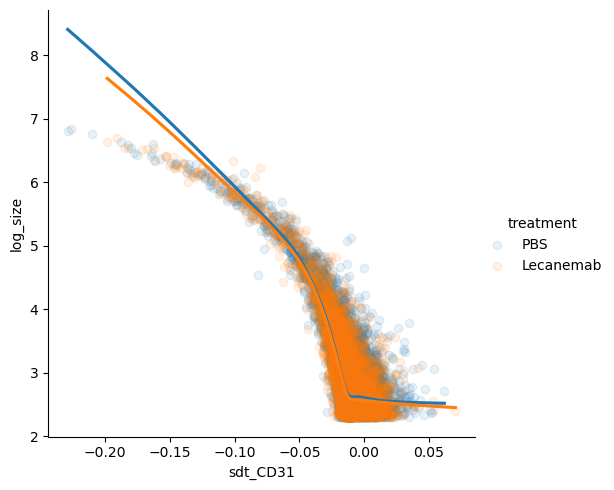

In [13]:
sns.lmplot(
    data=df.sample(20000),
    x="sdt_CD31",
    y="log_size",
    hue="treatment",
    scatter_kws={'alpha':0.1},
    lowess=True
)

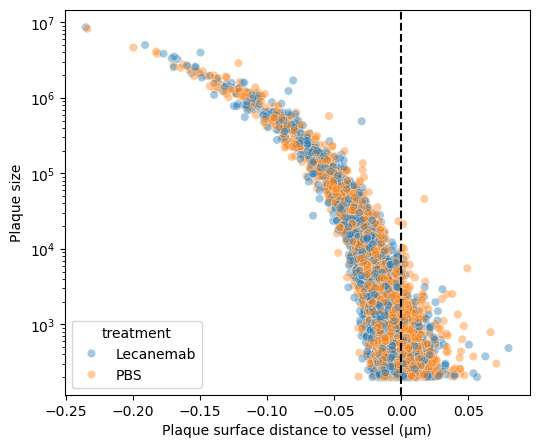

In [31]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df.sample(20000),
    x="sdt_CD31",
    y="nvoxels",
    hue="treatment",
    alpha=0.4
)

plt.yscale("log")
plt.axvline(0,color="black",ls="--")
plt.xlabel("Plaque surface distance to vessel (mm)")
plt.ylabel("Plaque size")
plt.show()

In [35]:
conditions = [
    df["sdt_CD31"] < 0,
    (df["sdt_CD31"] >= 0) & (df["sdt_CD31"] < 0.1),
    df["sdt_CD31"] >= 1
]

labels = ["vascular", "perivascular", "parenchymal"]

df["plaque_type"] = np.select(conditions, labels, default="unknown")

<Axes: xlabel='plaque_type', ylabel='count'>

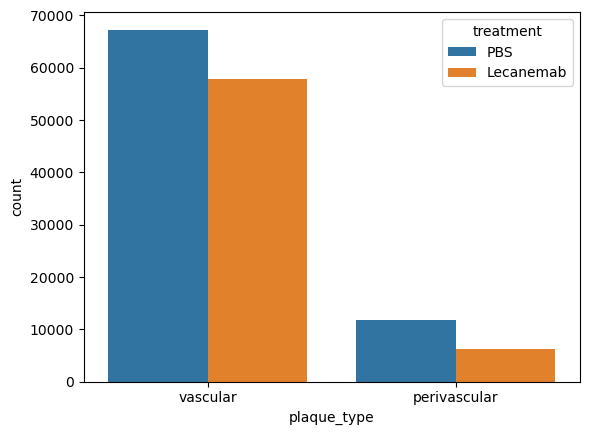

In [36]:
sns.countplot(data=df, x="plaque_type", hue="treatment")

## 4️⃣ 2D spatial plaque density

In [ ]:
plt.figure(figsize=(6,6))

sns.kdeplot(
    data=df,
    x="template_x",
    y="template_y",
    hue="treatment",
    fill=True,
    levels=30,
    alpha=0.4
)

plt.gca().set_aspect("equal")
plt.show()

## 6️⃣ Size-weighted plaque distribution

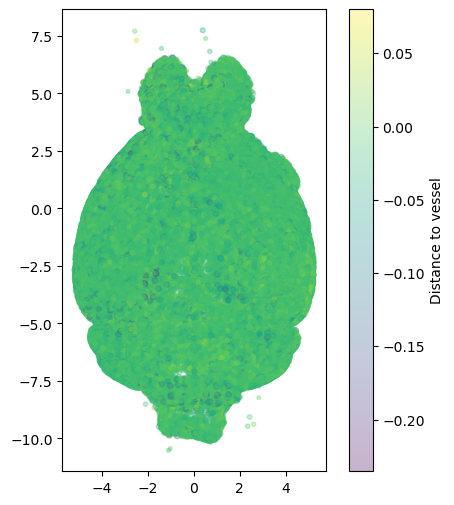

In [14]:
plt.figure(figsize=(6,6))

plt.scatter(
    df["template_x"],
    df["template_y"],
    s=np.log10(df["nvoxels"]+1)*3,
    c=df["sdt_CD31"],
    alpha=0.3
)

plt.colorbar(label="Distance to vessel")
plt.gca().set_aspect("equal")
plt.show()

In [15]:
df.groupby("treatment").agg(
    n_plaques=("nvoxels","size"),
    median_size=("nvoxels","median"),
    mean_size=("nvoxels","mean"),
    median_dist=("sdt_CD31","median"),
    mean_dist=("sdt_CD31","mean")
)

,n_plaques,median_size,mean_size,median_dist,mean_dist
treatment,,,,,
Lecanemab,64117,486.0,15380.299187,-0.012586,-0.013439
PBS,79014,494.0,15331.478244,-0.012034,-0.011928


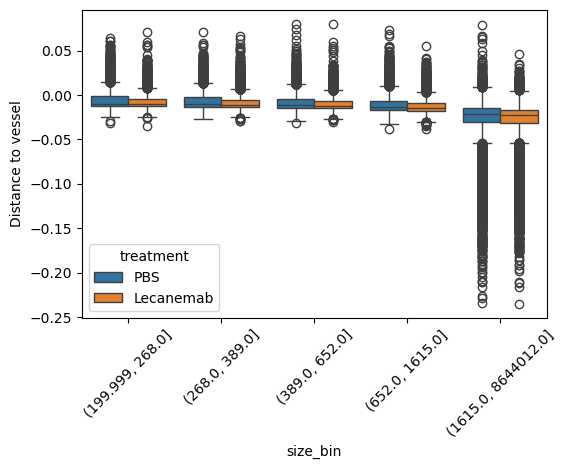

In [186]:
df['size_bin'] = pd.qcut(df['nvoxels'], 5)

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='size_bin', y='sdt_CD31', hue='treatment')
plt.xticks(rotation=45)
plt.ylabel("Distance to vessel")
plt.show()

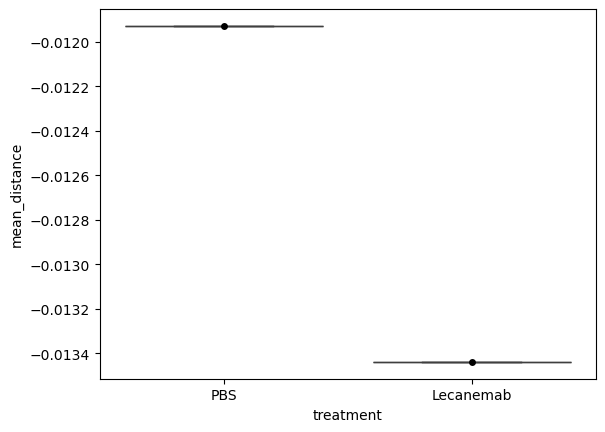

In [187]:
subject_stats = df.groupby(['subject','treatment']).agg(
    mean_distance=('sdt_CD31','mean'),
    median_distance=('sdt_CD31','median'),
    mean_size=('nvoxels','mean'),
    n_plaques=('nvoxels','size')
).reset_index()

sns.boxplot(data=subject_stats, x='treatment', y='mean_distance')
sns.stripplot(data=subject_stats, x='treatment', y='mean_distance', color='black')
plt.show()

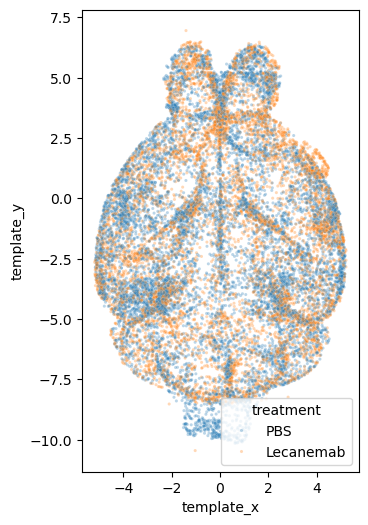

In [188]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=df.sample(20000),
    x='template_x',
    y='template_y',
    hue='treatment',
    alpha=0.3,
    s=5
)
plt.gca().set_aspect('equal')
plt.show()

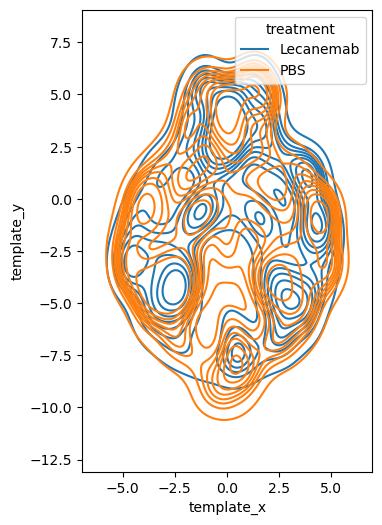

In [189]:
plt.figure(figsize=(6,6))
sns.kdeplot(
    data=df.sample(20000),
    x='template_x',
    y='template_y',
    hue='treatment'
)
plt.gca().set_aspect('equal')
plt.show()

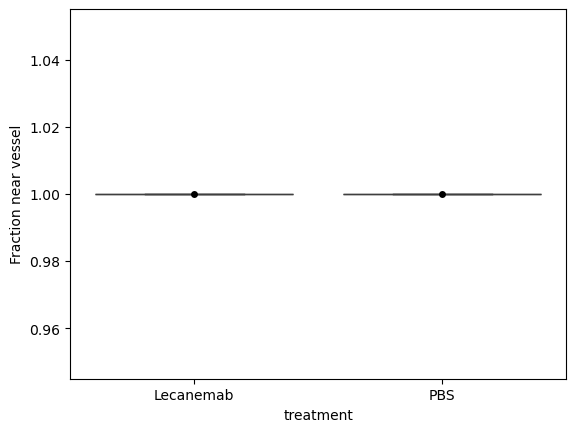

In [191]:
threshold = 20

df['near_vessel'] = df['sdt_CD31'] < threshold

near_stats = df.groupby(['subject','treatment'])['near_vessel'].mean().reset_index()

sns.boxplot(data=near_stats, x='treatment', y='near_vessel')
sns.stripplot(data=near_stats, x='treatment', y='near_vessel', color='black')
plt.ylabel("Fraction near vessel")
plt.show()

In [16]:
import numpy as np

voxel_vol = 1.6 * 1.6 * 2.75  # um^3

df = df.copy()
df["plaque_vol_um3"] = df["nvoxels"] * voxel_vol
df["equiv_diam_um"] = 2 * ((3 * df["plaque_vol_um3"]) / (4 * np.pi)) ** (1/3)

for thr in [10, 30, 50, 100, 300, 1000, 10000]:
    d = 2 * ((3 * (thr * voxel_vol)) / (4 * np.pi)) ** (1/3)
    print(f"{thr:>6} voxels -> {d:0.2f} um equiv diameter")

    10 voxels -> 5.12 um equiv diameter
    30 voxels -> 7.39 um equiv diameter
    50 voxels -> 8.76 um equiv diameter
   100 voxels -> 11.04 um equiv diameter
   300 voxels -> 15.92 um equiv diameter
  1000 voxels -> 23.78 um equiv diameter
 10000 voxels -> 51.23 um equiv diameter


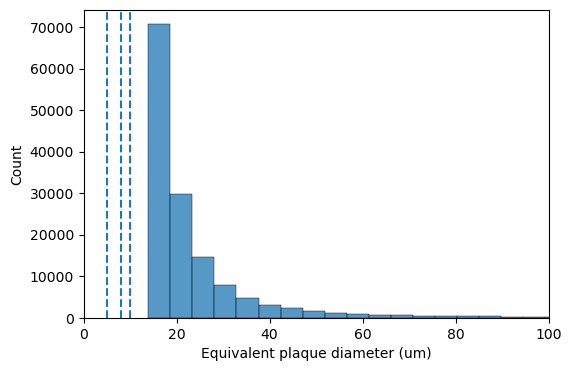

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df["equiv_diam_um"], bins=100)
plt.xlim((0,100))
plt.axvline(5, ls="--")
plt.axvline(8, ls="--")
plt.axvline(10, ls="--")
plt.xlabel("Equivalent plaque diameter (um)")
plt.show()

# old code below:

In [163]:
#make masks first:
plaques = df['nvoxels']< 

#sdt is signed distance of the plaque to vessel, adjusted by the vessel radius (assuming spherical)
#  so negative if inside or overlapping with vessel, and positive is distant from vessel
plaques_inside_vessels = df['sdt_CD31'] < 0  & plaques
plaques_outside_vessels = df['sdt_CD31'] > 0  & plaques

In [174]:
df_plaques_pbs = df.query("(nvoxels <2000 ) & treatment == 'PBS'")
df_plaques_leq = df.query("(nvoxels <2000 ) & treatment == 'Lecanemab'")

print(df_plaques_pbs.nvoxels.sum())
print(df_plaques_leq.nvoxels.sum())
print(29/36)

36619504.0
29574370.0
0.8055555555555556


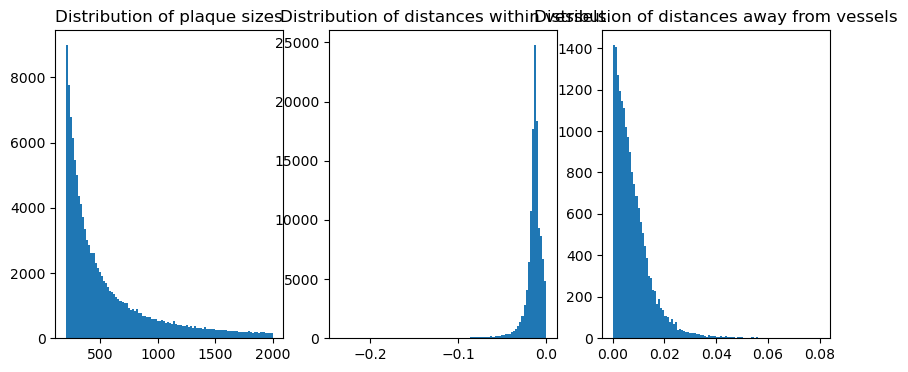

In [175]:
plaque_size = df[plaques]['nvoxels'].to_numpy()
signed_dist_to_vessels = df[plaques]['sdt_CD31'].to_numpy()


distances_inside_vessels = df[plaques_inside_vessels]['sdt_CD31'].to_numpy()
distances_outside_vessels = df[plaques_outside_vessels]['sdt_CD31'].to_numpy()

fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(10,4))
axes[0].set_title("Distribution of plaque sizes")
axes[0].hist(plaque_size,bins=100);


axes[1].set_title("Distribution of distances within vessels")
axes[1].hist(distances_inside_vessels,bins=100);


axes[2].set_title("Distribution of distances away from vessels")
axes[2].hist(distances_outside_vessels,bins=100);

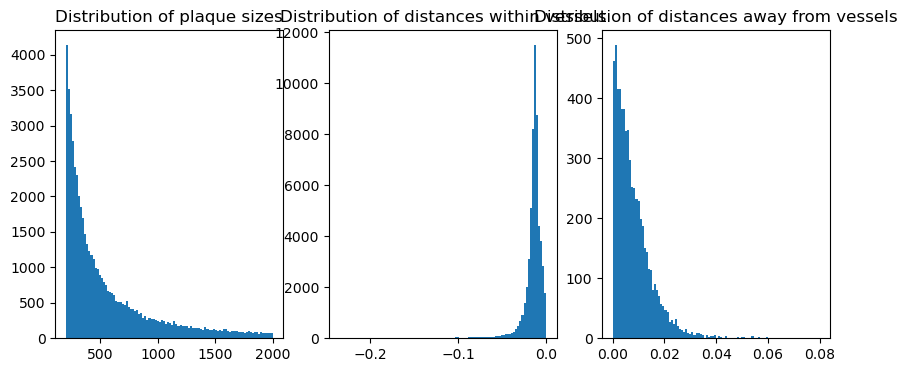

In [96]:
plaque_size = df[plaques]['nvoxels'].to_numpy()
signed_dist_to_vessels = df[plaques]['sdt_CD31'].to_numpy()


distances_inside_vessels = df[plaques_inside_vessels]['sdt_CD31'].to_numpy()
distances_outside_vessels = df[plaques_outside_vessels]['sdt_CD31'].to_numpy()

fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(10,4))
axes[0].set_title("Distribution of plaque sizes")
axes[0].hist(plaque_size,bins=100);


axes[1].set_title("Distribution of distances within vessels")
axes[1].hist(distances_inside_vessels,bins=100);


axes[2].set_title("Distribution of distances away from vessels")
axes[2].hist(distances_outside_vessels,bins=100);

In [ ]:

\